# 분류의 평가 방법

* 정확도 accuracy
* 오차행렬 Confusion Matrix
* 정밀도 Precision
* 재현율 recall
* F1 스코어
* Roc AUC

In [2]:
# 정확도의 경우는 데이터가 라벨이 불균형한 경우 단독으로 사용해서는 안된다, 왜냐하면  YES가 9 NO가 1인 라벨데이터에서 모델이 전부다 YES라고하더라도 정확도는 90%

In [22]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix


def get_clf_eval(y_test,pred):
    confusion=confusion_matrix(y_test,pred)
    accuracy=accuracy_score(y_test,pred)
    precision=precision_score(y_test,pred)
    recall=recall_score(y_test,pred)
    print('오차행렬')
    print(confusion)
    print(f'정확도{accuracy},재현율{recall},정밀도{precision}')

In [16]:
from sklearn.preprocessing import LabelEncoder
# 전체 전처리 함수 

#null 처리 함수
def fillna(df):
    df['Age'].fillna(df['Age'].mean(),inplace=True)
    df['Cabin'].fillna('N',inplace=True)
    df['Embarked'].fillna('N',inplace=True)
    df['Fare'].fillna(0,inplace=True)
    return df

#머신러닝 알고리즘에서 불필요한 피처제거
def drop_feature(df):
    df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)
    return df

#레이블인코딩

def format_feature(df):
    df['Cabin']=df['Cabin'].str[:1]
    feature= ['Cabin','Sex','Embarked']
    for i in feature:
        Ll=LabelEncoder()
        Ll.fit(df[i])
        df[i]=Ll.transform(df[i])
    return df

#전처리 함수 호출

def total_transform_feature(df):
    df=fillna(df)
    df=drop_feature(df)
    df=format_feature(df)
    return df

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


titanic_df=pd.read_csv('titanic_train.csv')
y_titanic_df=titanic_df['Survived']
x_titanic_df=titanic_df.drop('Survived',axis=1)
x_titanic_df_trans=total_transform_feature(x_titanic_df)

X_train,X_test,y_train,y_test=train_test_split(x_titanic_df_trans,y_titanic_df,test_size=0.2,random_state=11)

lr=LogisticRegression(solver='liblinear')

lr.fit(X_train,y_train)
pred=lr.predict(X_test)
get_clf_eval(y_test,pred)

오차행렬
[[108  10]
 [ 14  47]]
정확도0.8659217877094972,재현율0.7704918032786885,정밀도0.8245614035087719


C:\Users\gomin\AppData\Local\Temp\ipykernel_15068\2992066350.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)
C:\Users\gomin\AppData\Local\Temp\ipykernel_15068\2992066350.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

In [29]:
# 정밀도와 재현율의 trade-off
# 사이킷런은 어떤 레이블에 속하는지 정하기위해 결정확률을 정하고  더 큰 확률값에 따라 1이냐 0이냐 배치를함
# 이런확률은? predict_proba()

pred_proba=lr.predict_proba(X_test)
pred=lr.predict(X_test)

print(pred_proba[:3])
print(pred[:3])

[[0.44935228 0.55064772]
 [0.86335513 0.13664487]
 [0.86429645 0.13570355]]
[1 0 0]


In [35]:
#정밀도와 재현율 이해하기 

from sklearn.preprocessing import Binarizer

custom_threshold=0.5

pred_proba1=pred_proba[:,1].reshape(-1,1)

binar=Binarizer(threshold=custom_threshold)
custom_pred=binar.fit_transform(pred_proba1)

get_clf_eval(y_test,custom_pred) # 여기서 custom_pred는 0,1처럼 양성 or 음성으로 나옴 그걸 y_test와 비교하는것 

오차행렬
[[108  10]
 [ 14  47]]
정확도0.8659217877094972,재현율0.7704918032786885,정밀도0.8245614035087719


In [87]:
# threshold이 낮아질수록 재현율이 높아지고, 정밀도가 낮아짐  1로예측하는 경우의수가 많아지기 때문임

thresholds=[0.2,0.3,0.4]

def get_eval_by_thresholds(y_test,pred_proba_c1, thresholds):
    for i in thresholds:
        binar=Binarizer(threshold=i)           # pred_proba_C1은 pred값에 양성 축 즉 [:,1] 을 2차원으로 바꾼것  
        custom_pred=binar.fit_transform(pred_proba_c1) # thres hold값에 따라 예측하는 양성 음성값이 바뀌니까 custom_pred값도 바뀌고 그게 get_clf로 들어감
        get_clf_eval(y_test,custom_pred) 



In [55]:
# precision_recall_curve()
import numpy as np

from sklearn.metrics import precision_recall_curve

#1일때 예측확률
pred_proba_class=lr.predict_proba(X_test)[:,1]

# 실제값 레이블이 1일때 , precision, recall,threshold 출력
precision,recall,threshold=precision_recall_curve(y_test,pred_proba_class)
print(threshold.shape)

# 샘플로 10개추출, 
thr_index=np.arange(0,threshold.shape[0],15)
print(thr_index)
print(np.round(threshold[thr_index],2))

# precision, recall값을 index로  찾기
print(np.round(precision[thr_index],3))
print(np.round(recall[thr_index],3))

(165,)
[  0  15  30  45  60  75  90 105 120 135 150]
[0.02 0.11 0.13 0.14 0.16 0.24 0.32 0.45 0.62 0.73 0.87]
[0.341 0.372 0.401 0.44  0.505 0.598 0.688 0.774 0.915 0.968 0.938]
[1.    1.    0.967 0.902 0.902 0.902 0.869 0.787 0.705 0.492 0.246]


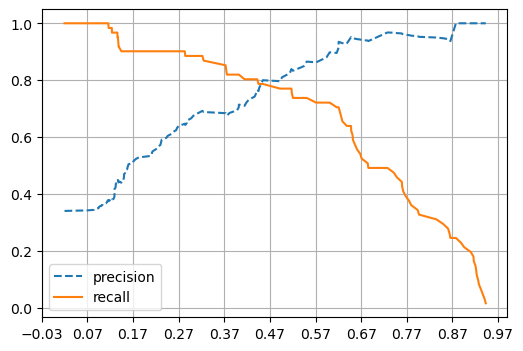

In [65]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def precision_recall_curve_plot(y_test,pred_proba_c1):
    precision,recall,threshold=precision_recall_curve(y_test,pred_proba_c1)

    # x축을 threshold값, y축은 정밀도, 재현율 값으로  plot 실행
    plt.figure(figsize=(6,4))
    threshold_boundary=threshold.shape[0]
    plt.plot(threshold,precision[0:threshold_boundary],label='precision',linestyle='--')
    plt.plot(threshold,recall[0:threshold_boundary],label='recall')

    # threshold 값 X 축의 Scale을 0.1로 변겅
    start,end = plt.xlim()
    plt.xticks(np.round(np.arange(start,end,0.1),2))

    # x축,y축 label과 legend, 그리고 grid 설정
    plt.grid()
    plt.legend()
    plt.show()

precision_recall_curve_plot(y_test,lr.predict_proba(X_test)[:,1])

In [69]:
# 정밀도와 재현율의 맹점
# positive 임곗값을 변경을 어떻게하느냐에 따라 정밀도와 재현율의 수치가 바뀜 정밀도와 재현율의 수치를 적절하게 조합해
# 종합적인 성능 평가에 사용될 수 있는 지표가 필요한데 => f1 score

from sklearn.metrics import f1_score

f1=f1_score(y_test,pred)
print(f'{f1}')


0.7966101694915254


In [92]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix
from sklearn.metrics import f1_score

def get_clf_eval(y_test,pred):
    confusion=confusion_matrix(y_test,pred)
    accuracy=accuracy_score(y_test,pred)
    precision=precision_score(y_test,pred)
    recall=recall_score(y_test,pred)
    #f1 score 추가
    f1=f1_score(y_test,pred)

    print('오차행렬')
    print(confusion)
    print(f'정확도{accuracy},재현율{recall},정밀도{precision},f1-score{f1}')

thresholds  = [0.4,0.5,0.55,0.6]
pred_proba=lr.predict_proba(X_test)
get_eval_by_thresholds(y_test,pred_proba[:,1].reshape(-1,1),thresholds)


오차행렬
[[97 21]
 [11 50]]
정확도0.8212290502793296,재현율0.819672131147541,정밀도0.704225352112676,f1-score0.7575757575757576
오차행렬
[[108  10]
 [ 14  47]]
정확도0.8659217877094972,재현율0.7704918032786885,정밀도0.8245614035087719,f1-score0.7966101694915254
오차행렬
[[111   7]
 [ 16  45]]
정확도0.8715083798882681,재현율0.7377049180327869,정밀도0.8653846153846154,f1-score0.7964601769911505
오차행렬
[[113   5]
 [ 17  44]]
정확도0.8770949720670391,재현율0.7213114754098361,정밀도0.8979591836734694,f1-score0.8


In [109]:
# roc 곡선과 auc
from sklearn.metrics import roc_curve

#레이블 값이 1일때의 예측확률을 추출

pred_proba_class1=lr.predict_proba(X_test)[:,1]

FPR,TPR,Thresholds = roc_curve(y_test,pred_proba_class1)  # FPR을 0으로 만들려면 임계값을 개처높여서 아무것도 1로 예측하지 못하게, 1로만들려면 임계값을 내려셔 모두가 1이되게
# 임계값에 따라 FPR,TPR값이 바뀌는데 현재 입계값은 디폴트값을씀
thr_index=np.arange(1,Thresholds.shape[0],5) # 5개마다 추출



print(thr_index)
print(np.round(Thresholds[thr_index],2))

print(f'fpr 값은?{FPR[thr_index]}')
print(f'tpr 값은?{TPR[thr_index]}')

print(FPR)

[ 1  6 11 16 21 26 31 36 41 46]
[0.94 0.73 0.62 0.52 0.44 0.28 0.15 0.14 0.13 0.12]
fpr 값은?[0.         0.00847458 0.02542373 0.07627119 0.12711864 0.25423729
 0.57627119 0.61016949 0.74576271 0.84745763]
tpr 값은?[0.01639344 0.49180328 0.70491803 0.73770492 0.80327869 0.8852459
 0.90163934 0.95081967 0.96721311 1.        ]
[0.         0.         0.         0.         0.         0.00847458
 0.00847458 0.01694915 0.01694915 0.02542373 0.02542373 0.02542373
 0.04237288 0.04237288 0.05932203 0.05932203 0.07627119 0.07627119
 0.10169492 0.10169492 0.12711864 0.12711864 0.16949153 0.16949153
 0.20338983 0.20338983 0.25423729 0.25423729 0.3220339  0.34745763
 0.55932203 0.57627119 0.59322034 0.59322034 0.60169492 0.60169492
 0.61016949 0.61864407 0.66101695 0.6779661  0.69491525 0.74576271
 0.77966102 0.8220339  0.8220339  0.84745763 0.84745763 1.        ]


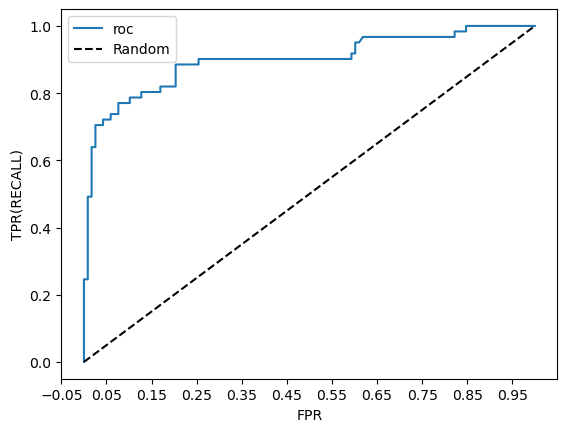

In [107]:
def roc_curve_plot(y_test,pred_proba_c1):
    #임계값에 따른 fpr,tpr값을 받음
    fprs,tprs,thresholds =roc_curve(y_test,pred_proba_c1)
    plt.plot(fprs,tprs,label='roc')
    #가운데 직선
    plt.plot([0,1],[0,1],'k--',label='Random')
    plt.xlabel('FPR')
    plt.ylabel('TPR(RECALL)')
    start,end= plt.xlim()
    plt.xticks(np.round(np.arange(start,end,0.1),2))
    plt.legend()
    plt.show()

roc_curve_plot(y_test,pred_proba[:,1])

In [111]:
# 따라서 곡선과 직선사이의 넓이 값이 넓을수록 좋음

from sklearn.metrics import roc_auc_score

pred_proba=lr.predict_proba(X_test)[:,1]
roc_score=roc_auc_score(y_test,pred_proba)
print(roc_score)

0.8986524034454015


In [1]:
def get_clf_eval(y_test,pred=None,pred_proba=None):
    confusion=confusion_matrix(y_test,pred)
    accuracy=accracy_score(y_test,pred)
    precision=precision_score(y_test,pred)
    recall=recall_score(y_test,pred)
    f1=f1_score(y_test,pred)
    #roc-auc추가
    roc_auc=roc_auc_score(y_test,pred_proba)
    print('오차행렬')
    print(confusion)
    print(f'정확도{accuracy},정밀도{precision},재현율{recall},f1{f1},auc{roc_auc}')